# Assay walkthrough: measuring the noise floor of an LLM eval

**Assay** is a statistics and audit layer for the eval harnesses you already run.
This notebook reproduces every headline figure on the project site, end to end,
from the shipped example fixtures. Run the cells top to bottom and you will
regenerate the PNGs in `results/figures/` and the numeric outputs in `results/`.

What you will reproduce:

1. **The reconciler** : frozen GSM8K generations scored two ways, gap attributed to the rule.
2. **Error bars and clustering** : why a naive SE understates uncertainty (~2.5x here).
3. **Power and the noise floor** : the smallest gap an eval of size *n* can resolve.
4. **The gate** : the underpowered-PR verdict, as a picture.
5. **Item response theory** : a 2PL fit, parameter recovery, and Fisher fast subsets.

**To run**
```bash
python -m pip install -e ".[notebook]"
jupyter nbconvert --to notebook --execute notebooks/assay_walkthrough.ipynb
```

**Honesty note.** The files in `examples/` are synthetic *illustrative* fixtures that use
the real on-disk schema. They exercise the exact code path but are not real model outputs,
so the numbers demonstrate the *method*, not a finding. The IRT section validates the fitter
by recovering *known* parameters from simulated data, which is the honest way to check a
trained component without real data.

In [1]:
# --- setup -----------------------------------------------------------------
import json, csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import assay
from assay import stats, irt
from assay.ingest import load_lm_eval_samples
from assay.reconcile import reconcile_gsm8k
from assay.check import check_samples
from assay.gate import run_gate

print("assay version:", assay.__version__)

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
EXAMPLES = ROOT / "examples"
RESULTS = ROOT / "results"
FIGS = RESULTS / "figures"
DOCS_FIGS = ROOT / "docs" / "figures"
for d in (RESULTS, FIGS, DOCS_FIGS):
    d.mkdir(parents=True, exist_ok=True)

INK, TEAL, MUTED, WARN, CRIT, GRID, VIOLET = "#10171C", "#0C8C7E", "#63727C", "#B26E12", "#C24248", "#D6DDD9", "#7C5CD0"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "font.size": 11,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "figure.dpi": 150,
    "savefig.bbox": "tight", "axes.spines.top": False, "axes.spines.right": False,
})

def save(fig, name):
    for folder in (FIGS, DOCS_FIGS):
        fig.savefig(folder / name, dpi=150)
    print("saved", name)

summary = {"note": "Illustrative fixtures. Numbers demonstrate the method, not a finding."}


assay version: 0.1.0


## 1. The reconciler: same generations, two parsers

lm-eval ships two answer extractors for GSM8K that run on the *same* output:
`strict-match` needs the `#### <number>` delimiter, `flexible-extract` takes the last
number anywhere. `assay reconcile` replays frozen generations through both and attributes
every point of the gap to the rule responsible.

In [2]:
rows = [json.loads(l) for l in open(EXAMPLES / "gsm8k_frozen.jsonl") if l.strip()]
res = reconcile_gsm8k(rows)
paired = stats.paired_mcnemar(res.strict_scores, res.flexible_scores)

print(f"frozen generations : {res.n}")
print(f"strict-match       : {res.strict_acc*100:6.2f}%")
print(f"flexible-extract   : {res.flexible_acc*100:6.2f}%")
print(f"delta              : {res.delta*100:+6.2f} pts  (recovered {res.flexible_recovered}, fooled {res.flexible_fooled})")
print(f"paired McNemar p   : {paired.p_value:.4g}")

summary["reconcile"] = {"n": res.n, "strict_acc": res.strict_acc, "flexible_acc": res.flexible_acc,
                        "delta": res.delta, "recovered": res.flexible_recovered, "fooled": res.flexible_fooled,
                        "paired_p_value": paired.p_value}
json.dump({**summary["reconcile"], "flips": [vars(f) for f in res.flips]},
          open(RESULTS / "reconcile_gsm8k.json", "w"), indent=2)


frozen generations : 24
strict-match       :  54.17%
flexible-extract   :  87.50%
delta              : +33.33 pts  (recovered 10, fooled 2)
paired McNemar p   : 0.03857


saved fig3_reconciler.png


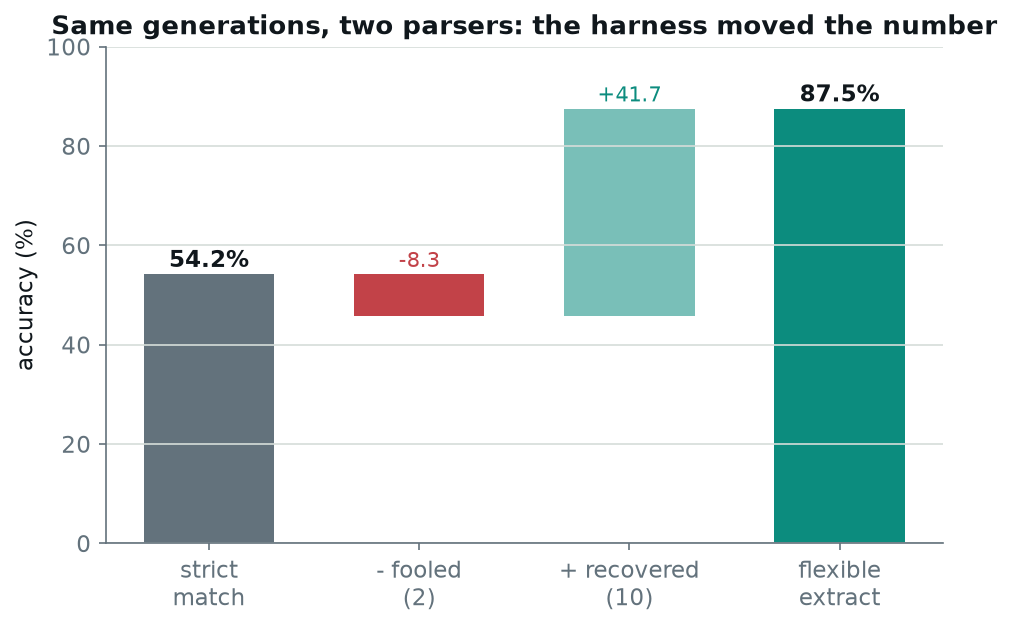

In [3]:
# Figure 3 : a waterfall from strict to flexible accuracy.
strict_pct, flex_pct = res.strict_acc*100, res.flexible_acc*100
rec_pts, fooled_pts = res.flexible_recovered/res.n*100, res.flexible_fooled/res.n*100
mid = strict_pct - fooled_pts

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(0, strict_pct, color=MUTED, width=0.62)
ax.bar(1, fooled_pts, bottom=mid, color=CRIT, width=0.62)
ax.bar(2, rec_pts, bottom=mid, color=TEAL, width=0.62, alpha=0.55)
ax.bar(3, flex_pct, color=TEAL, width=0.62)
for x, v in [(0, strict_pct), (3, flex_pct)]:
    ax.text(x, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.text(1, mid + fooled_pts + 1.5, f"-{fooled_pts:.1f}", ha="center", color=CRIT, fontsize=10)
ax.text(2, mid + rec_pts + 1.5, f"+{rec_pts:.1f}", ha="center", color=TEAL, fontsize=10)
ax.set_xticks(range(4)); ax.set_xticklabels(["strict\nmatch", f"- fooled\n({res.flexible_fooled})",
    f"+ recovered\n({res.flexible_recovered})", "flexible\nextract"])
ax.set_ylabel("accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("Same generations, two parsers: the harness moved the number")
ax.grid(axis="x", visible=False)
save(fig, "fig3_reconciler.png"); plt.show()


## 2. Error bars and clustering: naive SEs lie when items share a source

MMLU items are grouped by subject; scores within a group are correlated, so treating items
as i.i.d. understates uncertainty. Assay defaults to a CR2 (Bell-McCaffrey) cluster-robust
SE, cross-checked by a pairs-cluster bootstrap when clusters are few.

In [4]:
records = load_lm_eval_samples(EXAMPLES / "sample_lm_eval.jsonl", cluster_field="subject")
report = check_samples(records)
s = [r.score for r in records]; keys = [r.cluster_key for r in records]
mean, naive_se = stats.mean_and_naive_se(s)
cr2 = stats.cluster_robust_se(s, keys, method="CR2")
boot = stats.cluster_bootstrap_se(s, keys, n_boot=4000, seed=0)
print(f"accuracy {mean:.4f} | naive SE {naive_se:.4f} | CR2 {cr2.cluster_se:.4f} | bootstrap {boot:.4f} | inflation {cr2.inflation:.2f}x")
summary["clustering"] = {"accuracy": mean, "naive_se": naive_se, "cr2_se": cr2.cluster_se,
                         "bootstrap_se": boot, "inflation": cr2.inflation, "n_clusters": cr2.n_clusters}
json.dump(report, open(RESULTS / "check_mmlu_fixture.json", "w"), indent=2)


accuracy 0.5625 | naive SE 0.0724 | CR2 0.1790 | bootstrap 0.1651 | inflation 2.47x


saved fig2_error_bars.png


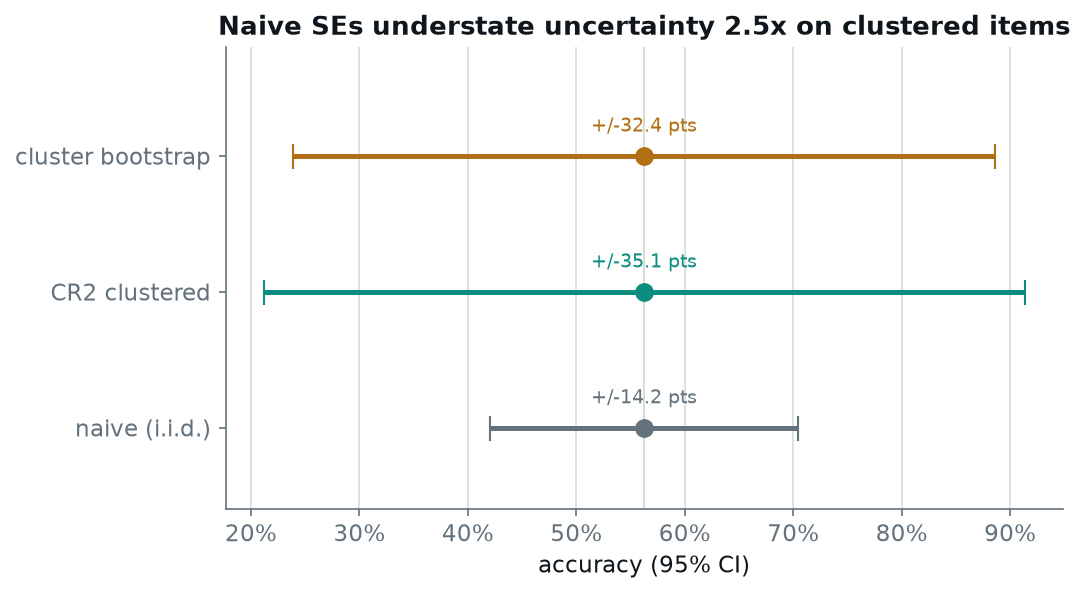

In [5]:
# Figure 2 : the same accuracy, three error bars.
z = 1.959964
methods = [("naive (i.i.d.)", naive_se, MUTED), ("CR2 clustered", cr2.cluster_se, TEAL), ("cluster bootstrap", boot, WARN)]
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for i, (label, se, color) in enumerate(methods):
    ax.errorbar(mean, i, xerr=z*se, fmt="o", color=color, capsize=6, elinewidth=2.4, markersize=8)
    ax.text(mean, i + 0.18, f"+/-{z*se*100:.1f} pts", ha="center", color=color, fontsize=9)
ax.axvline(mean, color=GRID, lw=1, zorder=0)
ax.set_yticks(range(len(methods))); ax.set_yticklabels([m[0] for m in methods]); ax.set_ylim(-0.6, len(methods)-0.2)
ax.set_xlabel("accuracy (95% CI)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
ax.set_title(f"Naive SEs understate uncertainty {cr2.inflation:.1f}x on clustered items")
ax.grid(axis="y", visible=False)
save(fig, "fig2_error_bars.png"); plt.show()


saved fig4_subject_clusters.png


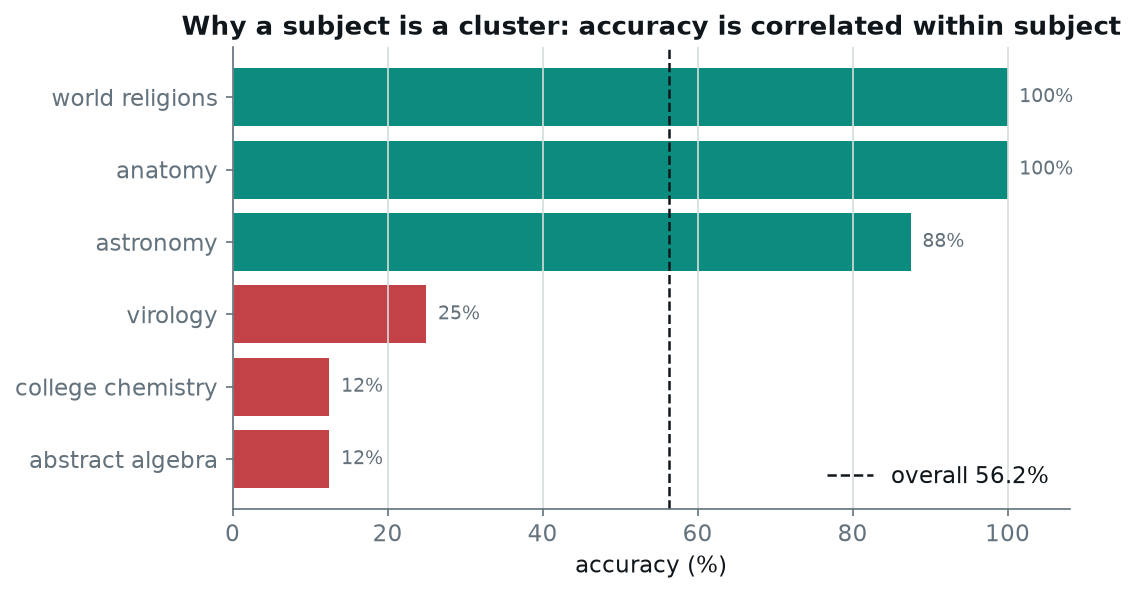

In [6]:
# Figure 4 : per-subject accuracy shows the within-subject correlation.
subjects, accs = [], []
for k in dict.fromkeys(keys):
    vals = [sc for sc, kk in zip(s, keys) if kk == k]
    subjects.append(k.replace("_", " ")); accs.append(100*np.mean(vals))
order = np.argsort(accs); subjects = [subjects[i] for i in order]; accs = [accs[i] for i in order]
colors = [CRIT if a < 40 else (WARN if a < 70 else TEAL) for a in accs]
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.barh(subjects, accs, color=colors)
ax.axvline(mean*100, color=INK, ls="--", lw=1.2, label=f"overall {mean*100:.1f}%")
for i, a in enumerate(accs): ax.text(a + 1.5, i, f"{a:.0f}%", va="center", fontsize=9, color=MUTED)
ax.set_xlim(0, 108); ax.set_xlabel("accuracy (%)")
ax.set_title("Why a subject is a cluster: accuracy is correlated within subject")
ax.legend(loc="lower right", frameon=False); ax.grid(axis="y", visible=False)
save(fig, "fig4_subject_clusters.png"); plt.show()


## 3. Power and the noise floor

The minimum detectable effect (MDE) follows Miller (arXiv:2411.00640, Eq 9):
$\text{MDE} = (z_{1-\alpha/2}+z_{\text{power}})\,\sigma/\sqrt{n}$, factor 7.85 at $\alpha=0.05$, power 0.8.

saved fig1_noise_floor_mde.png


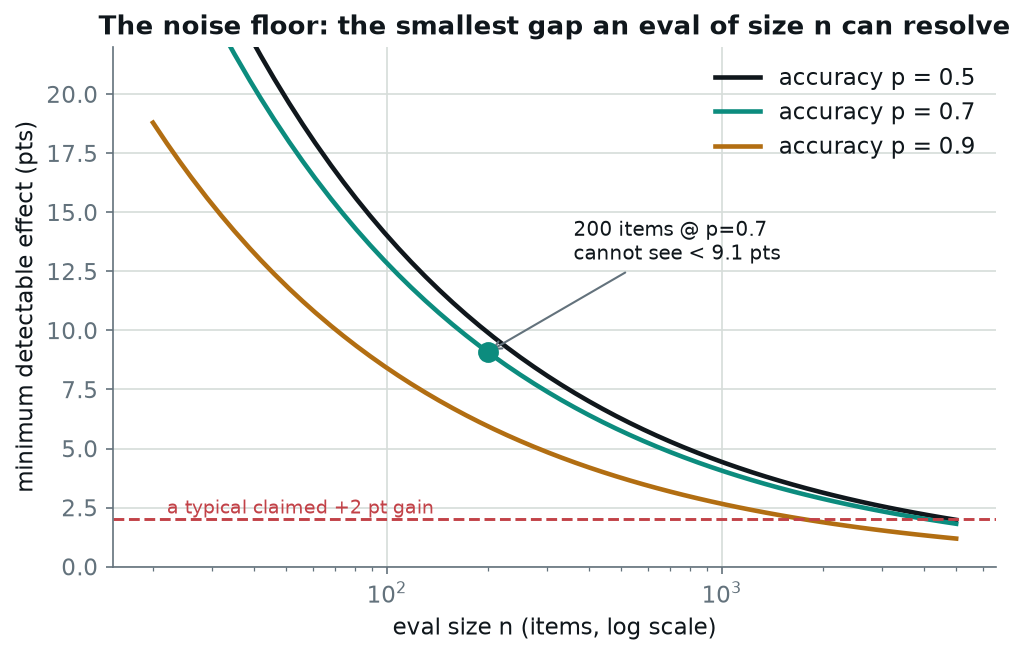

In [7]:
# Figure 1 (hero): the noise floor.
ns = np.unique(np.round(np.logspace(np.log10(20), np.log10(5000), 60)).astype(int))
fig, ax = plt.subplots(figsize=(7.6, 4.5))
for p, color in [(0.5, INK), (0.7, TEAL), (0.9, WARN)]:
    ax.plot(ns, [stats.mde_absolute(int(n), p)*100 for n in ns], color=color, lw=2.2, label=f"accuracy p = {p}")
ax.axhline(2.0, color=CRIT, ls="--", lw=1.4); ax.text(22, 2.25, "a typical claimed +2 pt gain", color=CRIT, fontsize=9)
mde200 = stats.mde_absolute(200, 0.7)*100
ax.plot([200], [mde200], "o", color=TEAL, ms=9, zorder=5)
ax.annotate(f"200 items @ p=0.7\ncannot see < {mde200:.1f} pts", xy=(200, mde200), xytext=(360, 13),
            arrowprops=dict(arrowstyle="->", color=MUTED), fontsize=9.5, color=INK)
ax.set_xscale("log"); ax.set_xlabel("eval size n (items, log scale)"); ax.set_ylabel("minimum detectable effect (pts)")
ax.set_ylim(0, 22); ax.set_title("The noise floor: the smallest gap an eval of size n can resolve")
ax.legend(loc="upper right", frameon=False)
save(fig, "fig1_noise_floor_mde.png"); plt.show()
with open(RESULTS / "mde_table.csv", "w", newline="") as fh:
    w = csv.writer(fh); w.writerow(["n", "mde_p0.5_pts", "mde_p0.7_pts", "mde_p0.9_pts"])
    for n in ns: w.writerow([int(n)] + [round(stats.mde_absolute(int(n), p)*100, 3) for p in (0.5, 0.7, 0.9)])
summary["mde_n200_p0.7_pts"] = mde200


saved fig5_paired_required_n.png


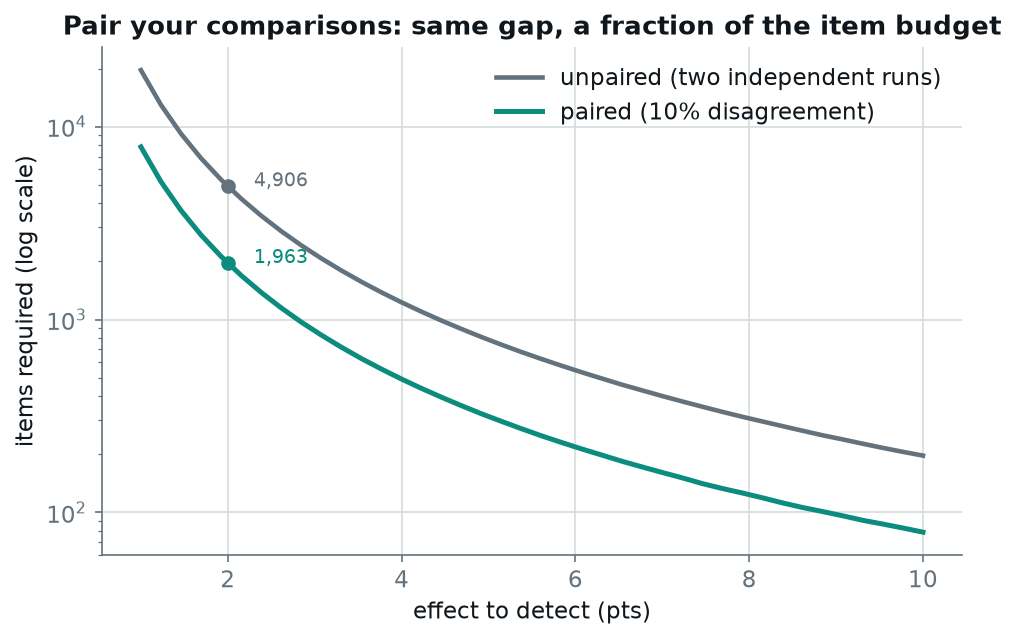

In [8]:
# Figure 5 : pairing pays.
effects = np.linspace(1, 10, 40)
su, sp = np.sqrt(0.25), np.sqrt(0.10)   # unpaired Bernoulli SD; paired ~ sqrt(10% disagreement)
nu = [stats.required_n(e/100, su) for e in effects]; npd = [stats.required_n(e/100, sp) for e in effects]
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(effects, nu, color=MUTED, lw=2.2, label="unpaired (two independent runs)")
ax.plot(effects, npd, color=TEAL, lw=2.4, label="paired (10% disagreement)")
for e in (2.0,):
    a2, p2 = stats.required_n(e/100, su), stats.required_n(e/100, sp)
    ax.plot([e, e], [p2, a2], color=GRID, lw=1); ax.plot(e, a2, "o", color=MUTED); ax.plot(e, p2, "o", color=TEAL)
    ax.annotate(f"{a2:,}", (e, a2), xytext=(e+0.3, a2), fontsize=9, color=MUTED)
    ax.annotate(f"{p2:,}", (e, p2), xytext=(e+0.3, p2), fontsize=9, color=TEAL)
ax.set_yscale("log"); ax.set_xlabel("effect to detect (pts)"); ax.set_ylabel("items required (log scale)")
ax.set_title("Pair your comparisons: same gap, a fraction of the item budget")
ax.legend(loc="upper right", frameon=False)
save(fig, "fig5_paired_required_n.png"); plt.show()
summary["required_n_2pt"] = {"unpaired": stats.required_n(0.02, su), "paired_10pct": stats.required_n(0.02, sp)}


## 4. The gate: is the claimed gain real?

`assay gate` compares two checkpoints on the same items and returns a verdict. The demo
fixtures are a candidate that is +2.0 pts over a 200-item eval. That delta sits *inside*
the noise floor, so the gate reads it as underpowered and prescribes the item budget that
would resolve it. This is the logic behind the bundled GitHub Action.

In [9]:
base = load_lm_eval_samples(EXAMPLES / "gate_baseline.jsonl", cluster_field="task")
cand = load_lm_eval_samples(EXAMPLES / "gate_candidate.jsonl", cluster_field="task")
cmap = {r.item_id: r for r in cand}
a = [r.score for r in base]; c = [cmap[r.item_id].score for r in base]; cl = [r.cluster_key for r in base]
g = run_gate(a, c, clusters=cl)
print(f"baseline {g.acc_baseline*100:.1f}%  ->  candidate {g.acc_candidate*100:.1f}%")
print(f"delta {g.delta*100:+.1f} pts | MDE {g.mde*100:.1f} pts | {g.test} p={g.p_value:.3g}")
print(f"VERDICT: {g.verdict}  (needs ~{g.items_needed:,} items to resolve)")
summary["gate"] = {"delta_pts": g.delta*100, "mde_pts": g.mde*100, "verdict": g.verdict,
                   "p_value": g.p_value, "items_needed": g.items_needed}


baseline 75.5%  ->  candidate 77.5%
delta +2.0 pts | MDE 5.6 pts | clustered-paired-z p=0.102
VERDICT: underpowered: delta below the noise floor  (needs ~1,570 items to resolve)


saved fig6_gate.png


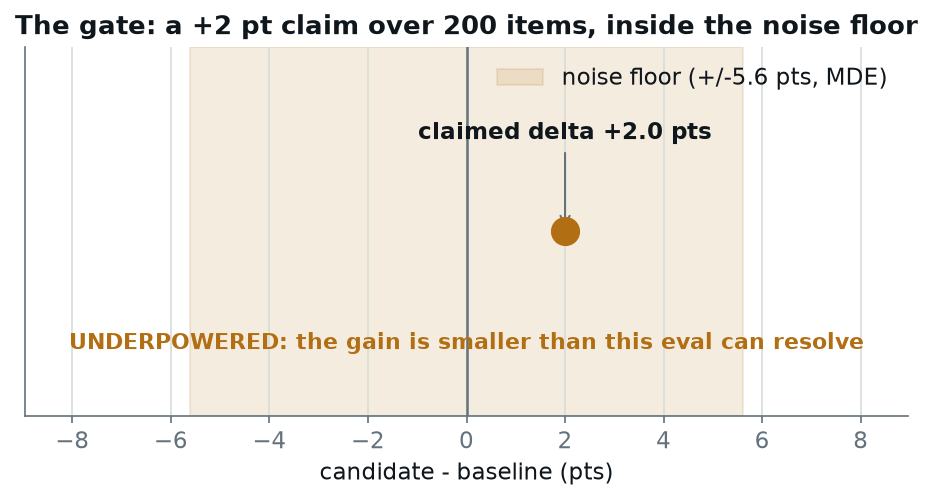

In [10]:
# Figure 6 : the underpowered PR. The claimed delta sits inside the noise floor band.
mde_p, delta_p = g.mde*100, g.delta*100
fig, ax = plt.subplots(figsize=(7.6, 3.2))
ax.axvspan(-mde_p, mde_p, color=WARN, alpha=0.13, label=f"noise floor (+/-{mde_p:.1f} pts, MDE)")
ax.axvline(0, color=MUTED, lw=1.2)
ax.plot(delta_p, 0, "o", color=WARN, ms=13, zorder=5)
ax.annotate(f"claimed delta {delta_p:+.1f} pts", xy=(delta_p, 0), xytext=(delta_p, 0.55),
            ha="center", color=INK, fontsize=11, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=MUTED))
ax.text(0, -0.7, "UNDERPOWERED: the gain is smaller than this eval can resolve",
        ha="center", color=WARN, fontsize=10.5, fontweight="bold")
ax.set_xlim(-mde_p*1.6, mde_p*1.6); ax.set_ylim(-1.1, 1.1)
ax.set_yticks([]); ax.set_xlabel("candidate - baseline (pts)")
ax.set_title("The gate: a +2 pt claim over 200 items, inside the noise floor")
ax.legend(loc="upper right", frameon=False); ax.grid(axis="y", visible=False)
save(fig, "fig6_gate.png"); plt.show()


## 5. Item response theory: a 2PL fit and Fisher fast subsets

Raw accuracy stops discriminating once models cluster near the top of a benchmark. A 2PL
item-response model keeps resolving differences and tells you which items carry information.
Assay fits 2PL by MAP with scipy L-BFGS (numpy/scipy only), and we validate it the honest
way: fit data simulated from *known* parameters and check the fit recovers them.

In [11]:
# Fit the shipped IRT fixture (simulated from a known truth) and check recovery.
Y = np.asarray([[float(x) for x in json.loads(l)["scores"]] for l in open(EXAMPLES / "irt_outcomes.jsonl") if l.strip()])
truth = json.load(open(EXAMPLES / "irt_truth.json"))
fit = irt.fit_2pl(Y)
r_theta = np.corrcoef(fit.theta, truth["theta"])[0, 1]
r_b = np.corrcoef(fit.b, truth["b"])[0, 1]
print(f"models x items {fit.n_models} x {fit.n_items} | converged {fit.converged}")
print(f"recovery correlation: theta r={r_theta:.3f}, difficulty b r={r_b:.3f}")
summary["irt"] = {"n_models": fit.n_models, "n_items": fit.n_items, "recover_theta_r": r_theta, "recover_b_r": r_b}


models x items 60 x 120 | converged True
recovery correlation: theta r=0.969, difficulty b r=0.907


saved fig7_irt_recovery.png


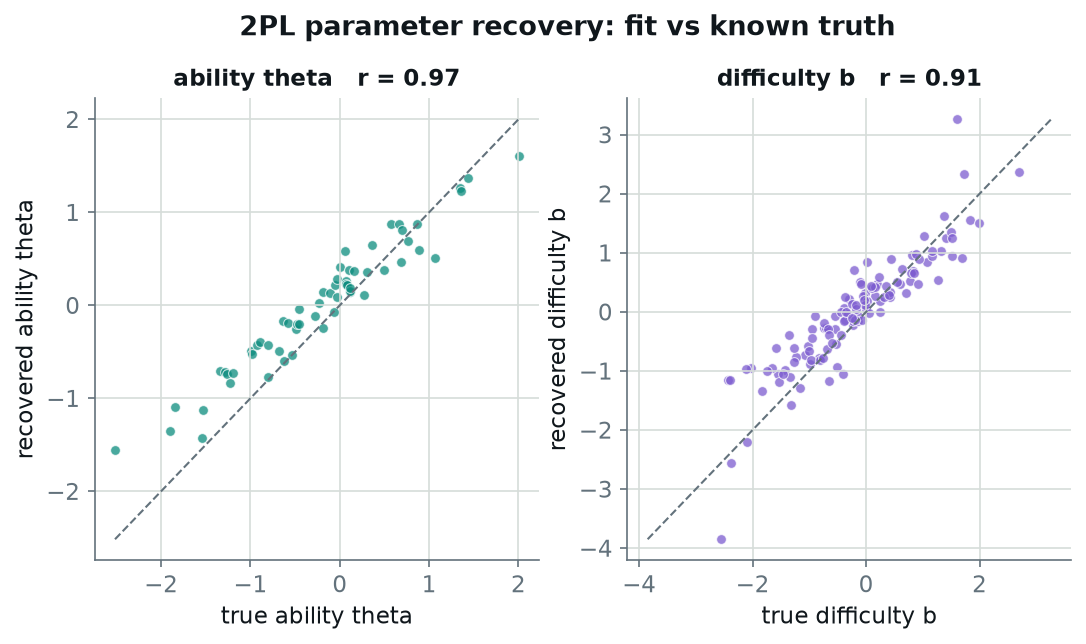

In [12]:
# Figure 7 : parameter recovery, recovered vs true.
fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.0))
for ax, key, col, lab in [(axes[0], "theta", TEAL, "ability theta"), (axes[1], "b", VIOLET, "difficulty b")]:
    tv = np.array(truth[key]); rv = getattr(fit, key)
    ax.scatter(tv, rv, s=22, color=col, alpha=0.75, edgecolor="white", linewidth=0.5)
    lo, hi = min(tv.min(), rv.min()), max(tv.max(), rv.max())
    ax.plot([lo, hi], [lo, hi], color=MUTED, ls="--", lw=1)
    ax.set_xlabel(f"true {lab}"); ax.set_ylabel(f"recovered {lab}")
    ax.set_title(f"{lab}   r = {np.corrcoef(tv, rv)[0,1]:.2f}", fontsize=11)
fig.suptitle("2PL parameter recovery: fit vs known truth", fontweight="bold", y=1.02)
save(fig, "fig7_irt_recovery.png"); plt.show()


saved fig8_irt_icc.png


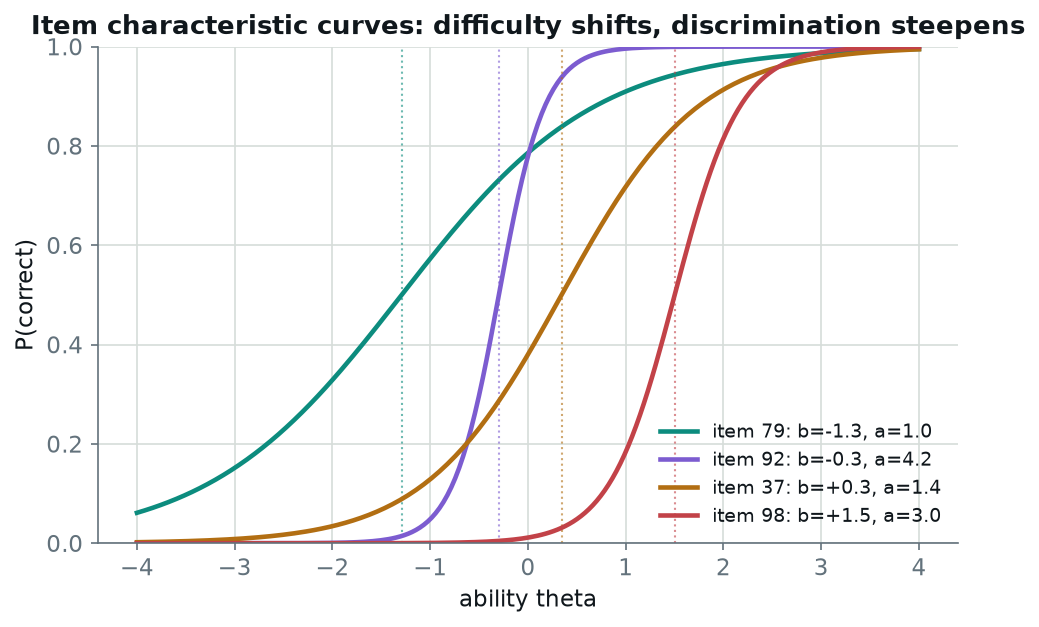

In [13]:
# Figure 8 : item characteristic curves for four fitted items across the difficulty range.
grid = np.linspace(-4, 4, 200)
picks = np.argsort(fit.b)[[5, len(fit.b)//3, 2*len(fit.b)//3, -6]]
fig, ax = plt.subplots(figsize=(7.4, 4.3))
cmap_cols = [TEAL, VIOLET, WARN, CRIT]
for col, i in zip(cmap_cols, picks):
    p = irt.sigmoid(fit.a[i] * (grid - fit.b[i]))
    ax.plot(grid, p, color=col, lw=2.2, label=f"item {i}: b={fit.b[i]:+.1f}, a={fit.a[i]:.1f}")
    ax.axvline(fit.b[i], color=col, ls=":", lw=1, alpha=0.6)
ax.set_xlabel("ability theta"); ax.set_ylabel("P(correct)"); ax.set_ylim(0, 1)
ax.set_title("Item characteristic curves: difficulty shifts, discrimination steepens")
ax.legend(loc="lower right", frameon=False, fontsize=9)
save(fig, "fig8_irt_icc.png"); plt.show()


saved fig9_ability_vs_accuracy.png


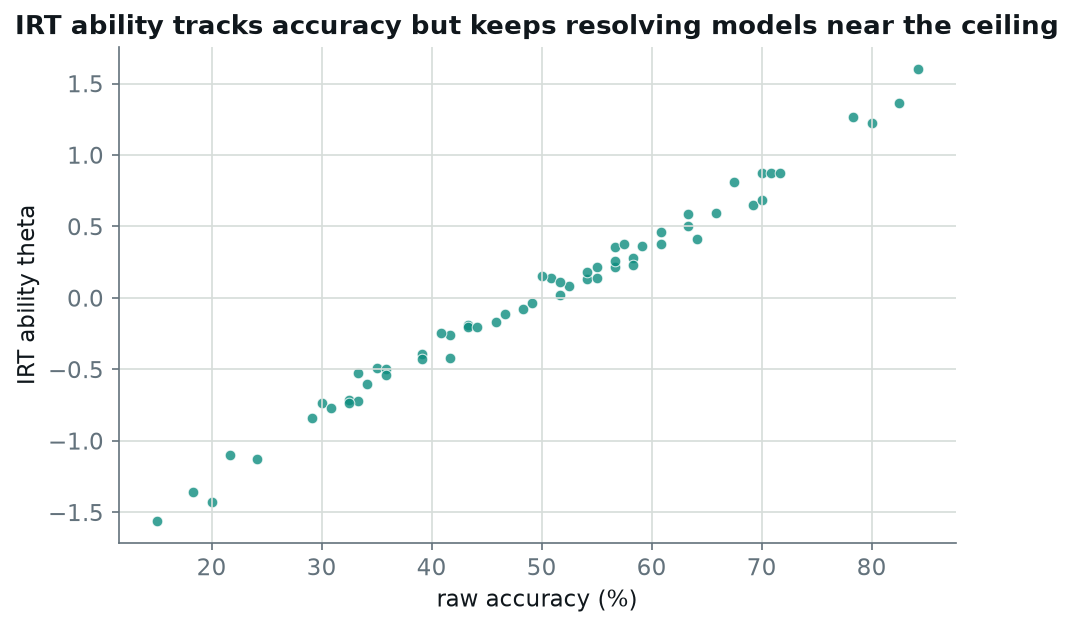

In [14]:
# Figure 9 : IRT ability vs raw accuracy. Ability gives a finer, monotone scale.
raw = Y.mean(axis=1)
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.scatter(raw*100, fit.theta, s=26, color=TEAL, alpha=0.8, edgecolor="white", linewidth=0.5)
ax.set_xlabel("raw accuracy (%)"); ax.set_ylabel("IRT ability theta")
ax.set_title("IRT ability tracks accuracy but keeps resolving models near the ceiling")
save(fig, "fig9_ability_vs_accuracy.png"); plt.show()
summary["irt"]["raw_vs_theta_r"] = float(np.corrcoef(raw, fit.theta)[0, 1])


saved fig10_fast_subset.png


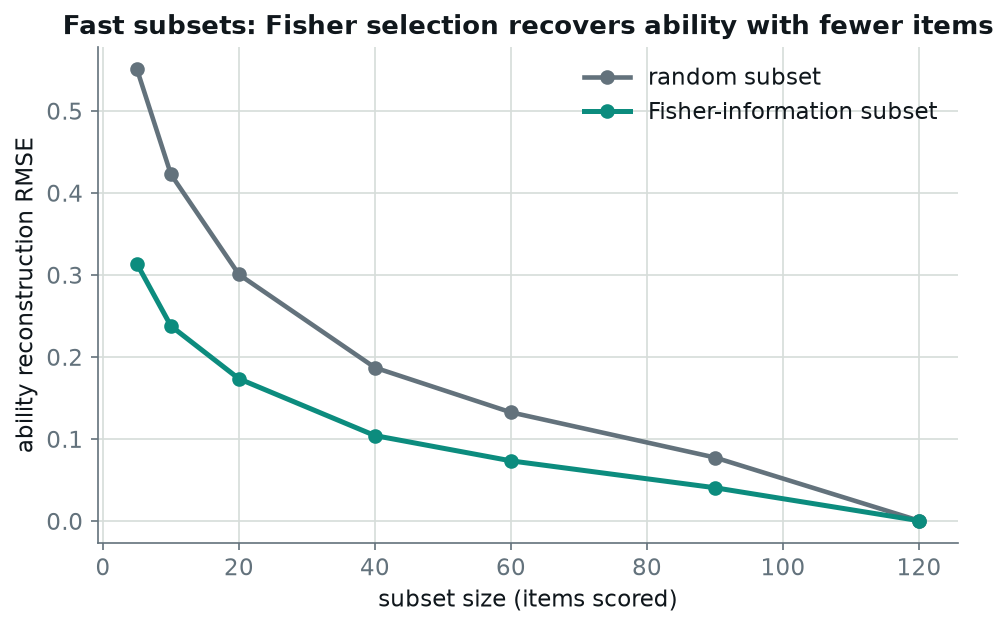

In [15]:
# Figure 10 : fast subsets. Fisher-selected items reconstruct ability better than random.
rng = np.random.default_rng(0)
ks = [5, 10, 20, 40, 60, 90, 120]
def rmse(idx):
    e = [(irt.estimate_ability(Y[m, idx], fit.a[idx], fit.b[idx])[0] - fit.theta[m])**2 for m in range(fit.n_models)]
    return float(np.sqrt(np.mean(e)))
smart = [rmse(irt.select_fast_subset(fit.a, fit.b, k)) for k in ks]
rand = [np.mean([rmse(rng.choice(fit.n_items, k, replace=False)) for _ in range(5)]) for k in ks]
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.plot(ks, rand, color=MUTED, lw=2.2, marker="o", label="random subset")
ax.plot(ks, smart, color=TEAL, lw=2.4, marker="o", label="Fisher-information subset")
ax.set_xlabel("subset size (items scored)"); ax.set_ylabel("ability reconstruction RMSE")
ax.set_title("Fast subsets: Fisher selection recovers ability with fewer items")
ax.legend(loc="upper right", frameon=False)
save(fig, "fig10_fast_subset.png"); plt.show()
summary["irt"]["fast_subset_rmse_k20"] = {"fisher": smart[2], "random": rand[2]}


## 6. Summary and reproducibility

Every number above was computed by the same functions the `assay` CLI calls, on the same
fixtures the test suite checks. Outputs land in `results/` and figures are mirrored into
`docs/figures/` so the site shows exactly what this notebook produced.

In [16]:
json.dump(summary, open(RESULTS / "summary.json", "w"), indent=2)
print("results/")
for p in sorted(RESULTS.rglob("*")):
    if p.is_file(): print("  ", p.relative_to(ROOT))
print("\nheadline numbers")
print(f"  reconciler delta        : {summary['reconcile']['delta']*100:+.1f} pts (illustrative)")
print(f"  SE inflation (clustered): {summary['clustering']['inflation']:.2f}x")
print(f"  noise floor @ n=200     : {summary['mde_n200_p0.7_pts']:.1f} pts")
print(f"  gate verdict            : {summary['gate']['verdict']}")
print(f"  IRT theta recovery r    : {summary['irt']['recover_theta_r']:.3f}")


results/
   results/README.md
   results/check_mmlu_fixture.json
   results/figures/fig10_fast_subset.png
   results/figures/fig1_noise_floor_mde.png
   results/figures/fig2_error_bars.png
   results/figures/fig3_reconciler.png
   results/figures/fig4_subject_clusters.png
   results/figures/fig5_paired_required_n.png
   results/figures/fig6_gate.png
   results/figures/fig7_irt_recovery.png
   results/figures/fig8_irt_icc.png
   results/figures/fig9_ability_vs_accuracy.png
   results/mde_table.csv
   results/reconcile_gsm8k.json
   results/summary.json

headline numbers
  reconciler delta        : +33.3 pts (illustrative)
  SE inflation (clustered): 2.47x
  noise floor @ n=200     : 9.1 pts
  gate verdict            : underpowered: delta below the noise floor
  IRT theta recovery r    : 0.969
